# Bài 1. Lập trình bài toán phân loại ảnh gồm 10 ký số trên tập dữ liệu MNIST
## 1. Khai báo thư viện và chuẩn bị dữ liệu

In [1]:
import numpy as np
from tensorflow import keras    # thư viện keras cho deep learning
import matplotlib.pyplot as plt # thư viện vẽ đồ thị
import time

# tải dataset mnist từ thư viện dataset chuẩn trong keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Thông tin tập train
print(f'Train: n={len(x_train)}') 
print(f'+ x_train: {x_train.shape}, range = [{np.min(x_train)}, {np.max(x_train)}]') 
print(f'+ y_train: {y_train.shape}, values= {np.unique(y_train)}') 

# Thông tin tập test
print(f'Test: n={len(x_test)}') 
print(f'+ x_test: {x_test.shape}, range = [{np.min(x_test)}, {np.max(x_test)}]') 
print(f'+ y_test: {y_test.shape}, values= {np.unique(y_test)}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: n=60000
+ x_train: (60000, 28, 28), range = [0, 255]
+ y_train: (60000,), values= [0 1 2 3 4 5 6 7 8 9]
Test: n=10000
+ x_test: (10000, 28, 28), range = [0, 255]
+ y_test: (10000,), values= [0 1 2 3 4 5 6 7 8 9]


## 2. Hiển thị dữ liệu

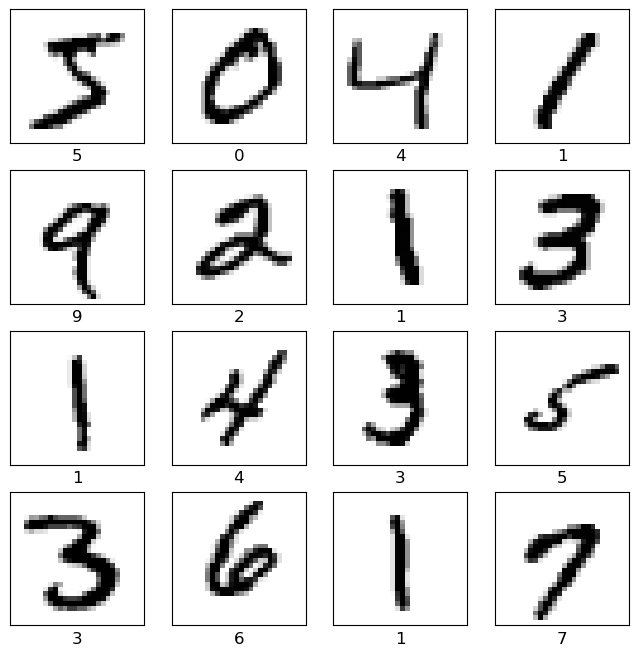

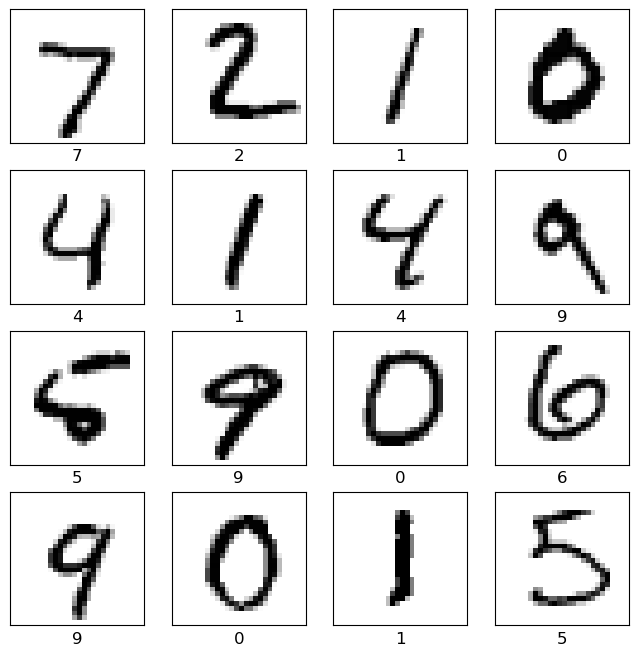

In [2]:
# Hiển thị dữ liệu train
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_train[i]}', fontsize = 12)
plt.show()

# Hiển thị dữ liệu test
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_test[i]}', fontsize = 12)
plt.show()

## 3. Tiền xử lý dữ liệu

In [3]:
# Biến đổi ảnh về miền trị [0,1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Mở rộng shape tại chiều cuối cùng (n_images,28,28) --> (n_images, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

# Chuyển đổi y_train, y_test sang dạng one-hot
num_classes = 10 # phân lớp 10 ký tự số (từ 0 đến 9)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


## 4. Xây dựng Model

In [4]:
# xóa các lưu trữ 
keras.backend.clear_session() 

# xây dựng model
input_shape = (28, 28, 1)
input_ = keras.Input(shape=input_shape)

# các blocks convolution để lấy features
# block 1
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(input_)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

# block 2
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

# classification layers 
x = keras.layers.Flatten()(x) 
x = keras.layers.Dropout(0.5)(x) 
output_ = keras.layers.Dense(num_classes, activation="softmax")(x) 

model = keras.Model(inputs=input_, outputs=output_) 
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Huấn luyện Model

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.9432 - loss: 0.1825 - val_accuracy: 0.9863 - val_loss: 0.0493
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 34s 80ms/step - accuracy: 0.9729 - loss: 0.0885 - val_accuracy: 0.9858 - val_loss: 0.0482
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - accuracy: 0.9763 - loss: 0.0769 - val_accuracy: 0.9887 - val_loss: 0.0367
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - accuracy: 0.9770 - loss: 0.0725 - val_accuracy: 0.9893 - val_loss: 0.0356
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.9799 - loss: 0.0657 - val_accuracy: 0.9873 - val_loss: 0.0485
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.9798 - loss: 0.0653 - val_accuracy: 0.9907 - val_loss: 0.0374
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.9818 - loss: 0.0581 - val_accuracy: 0.9887 - val_loss: 0.0441
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - accuracy: 0.9822 - loss: 0.0587 - 

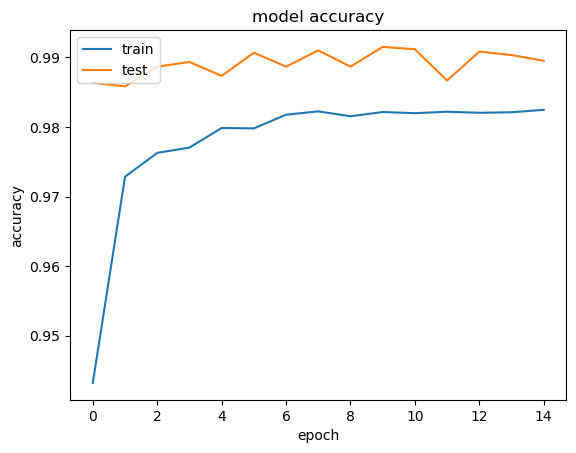

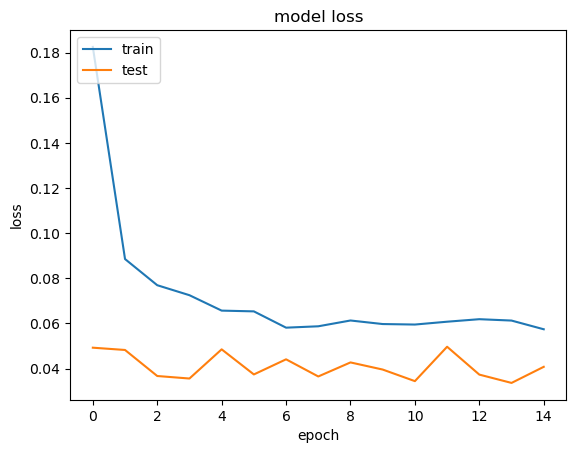

In [5]:
# khai báo learning rate, loss function, và model metric
model.compile(loss='categorical_crossentropy', 
              optimizer=keras.optimizers.Adam(learning_rate=0.01), 
              metrics=["accuracy"])

batch_size = 128
epochs = 15
starting_time = time.time()

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('> training time is %.4f minutes' % ((time.time() - starting_time)/60))

# summarize history for accuracy
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## 6. Lượng giá Model

Test loss: 0.03570263832807541
Test accuracy: 0.9894999861717224
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
False Cases: 105 / 10000


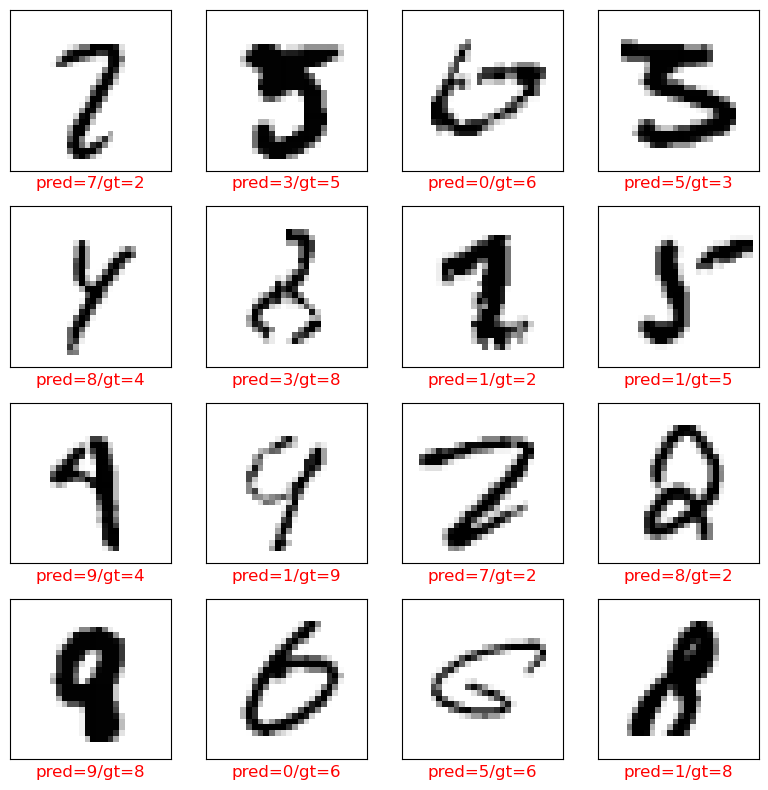

In [6]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

y_pred = model.predict(x_test)
y_pred_label = np.argmax(y_pred, axis = 1)
y_gt_label = np.argmax(y_test, axis = 1)

# Các vị trí bị sai
false_pos = np.where(y_pred_label != y_gt_label)[0]
print(f'False Cases: {len(false_pos)} / {len(y_gt_label)}')

# Hiển thị các trường hợp test sai
plt.figure(figsize=(8, 8))
for i in range(min(16, len(false_pos))):
    pos = false_pos[i]
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[pos].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(f'pred={y_pred_label[pos]}/gt={y_gt_label[pos]}', fontsize = 12, color='red')
plt.tight_layout()
plt.show()